1. Імпорти

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 500)

2. Завантаження датасету

In [4]:
CSV_PATH = "../data/raw/robustness_copilot.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)

Shape: (892, 16)


3. Перший огляд

In [5]:
df.head()

,index,project,body,methodName,relativePath,absolutePath,javaDoc,spanMethod,coverage,tokensPerMethod,tokensFirstLine,javaDocFirstSentence,perturbed_eval_1,pegasusPerturbed,pegagusPerturbedEntropy,pivotingPerturbed
0,1,cdk,"static AtomTypePattern[] loadPatterns(InputStream smaIn) throws IOException{\n List<AtomTypePattern> matchers = new ArrayList<AtomTypePattern>();\n BufferedReader br = new BufferedReader(new InputStreamReader(smaIn));\n String line = null;\n while ((line = br.readLine()) != null) {\n if (skipLine(line))\n continue;\n String[] cols = line.split("" "");\n String sma = cols[0];\n String symb = cols[1];\n try {\n matchers.add(new...",loadPatterns,org/openscience/cdk/forcefield/mmff/MmffAtomTypeMatcher.java,/tool/forcefield/src/main/java/org/openscience/cdk/forcefield/mmff/MmffAtomTypeMatcher.java,/**\n * Internal - load the SMARTS patterns for each atom type from MMFFSYMB.sma.\n *\n * @param smaIn input stream of MMFFSYMB.sma\n * @return array of patterns\n * @throws IOException\n */,215-241,"('loadPatterns', {'INSTRUCTION': {'covered': 62, 'missed': 0}, 'BRANCH': {'covered': 4, 'missed': 0}, 'LINE': {'covered': 14, 'missed': 0}, 'COMPLEXITY': {'covered': 3, 'missed': 0}, 'METHOD': {'covered': 1, 'missed': 0}})",154.0,13.0,Internal - load the SMARTS patterns for each atom type from MMFFSYMB.,Internal - for each type of atom from MMFFSYMB.sma loads the SMARTS models.,Load the patterns for each atom type from MMFFSYMB.,0.393088,Internal - load SMARTS models for each type of atom from MMFFSYMB.
1,3,dcache,"private static String toGroupName(String attribute){\n int pos = attribute.indexOf(';');\n if (pos > -1) {\n attribute = attribute.substring(0, pos);\n }\n return attribute.replace(""X"", ""XX"").replace(""."", ""X"");\n}",toGroupName,org/dcache/services/billing/text/BillingParserBuilder.java,/modules/dcache/src/main/java/org/dcache/services/billing/text/BillingParserBuilder.java,/**\n * Translates a attribute name into a name suitable for a named capturing group.\n */,252-261,"('toGroupName', {'INSTRUCTION': {'covered': 15, 'missed': 5}, 'BRANCH': {'covered': 1, 'missed': 1}, 'LINE': {'covered': 3, 'missed': 1}, 'COMPLEXITY': {'covered': 1, 'missed': 1}, 'METHOD': {'covered': 1, 'missed': 0}})",57.0,14.0,Translates a attribute name into a name suitable for a named capturing group.,"Given an attribute name as input, it translates an attribute name into a name suitable for a named capturing group.",A name is translated into a name suitable for a group.,0.093899,Translates an attribute name into a name that is appropriate for a named capture group.
2,4,matsim-libs,"void revisitNode(final Node n, final DijkstraNodeData data, final RouterPriorityQueue<Node> pendingNodes, final double time, final double cost, final Link outLink){\n pendingNodes.remove(n);\n data.visit(outLink, cost, time, getIterationId());\n pendingNodes.add(n, getPriority(data));\n}",revisitNode,org/matsim/pt/router/TransitLeastCostPathTree.java,/matsim/src/main/java/org/matsim/pt/router/TransitLeastCostPathTree.java,/**\n\t * Changes the position of the given Node n in the pendingNodes queue and\n\t * updates its time and cost information.\n\t *\n\t * @param n\n\t * The Node that is revisited.\n\t * @param data\n\t * The data for n.\n\t * @param pendingNodes\n\t * The nodes visited and not processed yet.\n\t * @param time\n\t * The time of the visit of n.\n\t * @param cost\n\t * The accumulated cost at the time of the visit of n.\n\t * @param outLin...,482-506,"('revisitNode', {'INSTRUCTION': {'covered': 19, 'missed': 0}, 'LINE': {'covered': 4, 'missed': 0}, 'COMPLEXITY': {'covered': 1, 'missed': 0}, 'METHOD': {'covered': 1, 'missed': 0}})",66.0,20.0,Changes the position of the given Node n in the pendingNodes queue and updates its time and cost information.,Updates time and cost information as node node location changes. The parameter outLink is the link through which we came to visit n.,The given Node n is in the pendingNodes queue and can be cha

4. Повний список колонок

In [6]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. index
2. project
3. body
4. methodName
5. relativePath
6. absolutePath
7. javaDoc
8. spanMethod
9. coverage
10. tokensPerMethod
11. tokensFirstLine
12. javaDocFirstSentence
13. perturbed_eval_1
14. pegasusPerturbed
15. pegagusPerturbedEntropy
16. pivotingPerturbed


5. Типи даних

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   index                    892 non-null    int64  
 1   project                  892 non-null    str    
 2   body                     892 non-null    str    
 3   methodName               892 non-null    str    
 4   relativePath             892 non-null    str    
 5   absolutePath             892 non-null    str    
 6   javaDoc                  892 non-null    str    
 7   spanMethod               892 non-null    str    
 8   coverage                 892 non-null    str    
 9   tokensPerMethod          892 non-null    float64
 10  tokensFirstLine          892 non-null    float64
 11  javaDocFirstSentence     892 non-null    str    
 12  perturbed_eval_1         892 non-null    str    
 13  pegasusPerturbed         892 non-null    str    
 14  pegagusPerturbedEntropy  892 non-null

6. Пропущені значення

In [8]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

7. Дублікати

In [9]:
print(
    "Duplicates:",
    df.duplicated().sum()
)

Duplicates: 0


8. Випадкові приклади

In [10]:
df.sample(5)

,index,project,body,methodName,relativePath,absolutePath,javaDoc,spanMethod,coverage,tokensPerMethod,tokensFirstLine,javaDocFirstSentence,perturbed_eval_1,pegasusPerturbed,pegagusPerturbedEntropy,pivotingPerturbed
273,297,tablesaw,public Row appendRow(){\n for (final Column<?> column : columnList) {\n column.appendMissing();\n }\n return row(rowCount() - 1);\n},appendRow,tech/tablesaw/api/Table.java,/core/src/main/java/tech/tablesaw/api/Table.java,"/**\n * Appends an empty row and returns a Row object indexed to the newly added row so values can be\n * set.\n *\n * <p>Intended usage:\n *\n * <p>for (int i = 0; ...) { Row row = table.appendRow(); row.setString(""name"", ""Bob"");\n * row.setFloat(""IQ"", 123.4f); ...etc. }\n */",1098-1112,"('appendRow', {'INSTRUCTION': {'covered': 22, 'missed': 0}, 'BRANCH': {'covered': 2, 'missed': 0}, 'LINE': {'covered': 4, 'missed': 0}, 'COMPLEXITY': {'covered': 2, 'missed': 0}, 'METHOD': {'covered': 1, 'missed': 0}})",36.0,21.0,Appends an empty row and returns a Row object indexed to the newly added row so values can be set.,"The function appends an empty row, returning a Row object pointing to the new inserted row in order to be set.",Appends an empty row and returns a Row object that is related to the new row.,1.069666,Adds a blank row and returns an indexed Row object to the newly added row so that values can be set.
505,553,dcache,"public static EnumSet<LoA> withImpliedLoA(Optional<EntityDefinition> entity, Collection<LoA> asserted){\n Map<LoA, LoA> mapping = entity.filter(PERSON::equals).map(e -> PERSONAL_EQUIVALENT_LOA).orElse(GENERIC_EQUIVALENT_LOA);\n EnumSet<LoA> result = EnumSet.copyOf(asserted);\n Collection<LoA> considered = asserted;\n do {\n EnumSet<LoA> additional = considered.stream().map(mapping::get).filter(Objects::nonNull).collect(Collectors.toCollection(() -> EnumSet.noneOf(LoA.class...",withImpliedLoA,org/dcache/auth/LoAs.java,/modules/common/src/main/java/org/dcache/auth/LoAs.java,"/**\n * Convert a set of asserted LoAs so it includes all equivalent LoAs.\n *\n * @param entity the kind of identity asserted, if known.\n * @param asserted a collection of LoA asserted by some external agent.\n * @return all LoAs for this identity.\n */",68-94,"('withImpliedLoA', {'INSTRUCTION': {'covered': 44, 'missed': 0}, 'BRANCH': {'covered': 2, 'missed': 0}, 'LINE': {'covered': 13, 'missed': 0}, 'COMPLEXITY': {'covered': 2, 'missed': 0}, 'METHOD': {'covered': 1, 'missed': 0}})",145.0,13.0,Convert a set of asserted LoAs so it includes all equivalent LoAs.,Translates a set of asserted LoAs in such a way to include all the equivalent LoAs.,All equivalent loAs can be converted so it includes a set of asserted loAs.,0.930003,Convert a set of asserted LoAs so that it includes all equivalent LoAs.
820,909,tablesaw,"DoubleColumn neg(){\n DoubleColumn newColumn = DoubleColumn.create(name() + ""[neg]"", size());\n for (int i = 0; i < size(); i++) {\n newColumn.set(i, getDouble(i) * -1);\n }\n return newColumn;\n}",neg,tech/tablesaw/columns/numbers/NumberMapFunctions.java,/core/src/main/java/tech/tablesaw/columns/numbers/NumberMapFunctions.java,"/**\n * For each item in the column, returns the same number with the sign changed. For example: -1.3\n * returns 1.3, 2.135 returns -2.135 0 returns 0\n */",336-346,"('neg', {'INSTRUCTION': {'covered': 32, 'missed': 0}, 'BRANCH': {'covered': 2, 'missed': 0}, 'LINE': {'covered': 4, 'missed': 0}, 'COMPLEXITY': {'covered': 2, 'missed': 0}, 'METHOD': {'covered': 1, 'missed': 0}})",60.0,16.0,"For each item in the column, returns the same number with the sign changed.",Returns the same number with a new sign for each item in the column. For instance: -1.3 yields 1.3; and 2.135 yields -2.135; 0 yields 0.,The number is returned for each item in the column.,0.403218,"For each item in the column, returns the same number with the modified sign."
221,243,cdk,"public void registerParameters(IGenerator<? extends IChemObject> generator){\n for (IGeneratorParameter<?>

9. Статистика числових колонок

In [11]:
numeric_cols = df.select_dtypes(
    include=np.number
)

numeric_cols.describe().T

,count,mean,std,min,25%,50%,75%,max
index,892.0,491.228700,285.446934,1.000000,244.750000,486.500000,737.250000,986.000000
tokensPerMethod,892.0,154.284753,218.202841,30.000000,52.000000,92.000000,175.250000,2943.000000
tokensFirstLine,892.0,15.912556,5.714414,10.000000,12.000000,14.000000,19.000000,45.000000
pegagusPerturbedEntropy,892.0,0.513773,0.349495,0.034119,0.273157,0.416202,0.653367,2.645704


10. Які є текстові колонки

In [17]:
text_cols = df.select_dtypes(include=["object", "string"])

list(text_cols)

['project',
 'body',
 'methodName',
 'relativePath',
 'absolutePath',
 'javaDoc',
 'spanMethod',
 'coverage',
 'javaDocFirstSentence',
 'perturbed_eval_1',
 'pegasusPerturbed',
 'pivotingPerturbed']

11. Розмір тексту у всіх текстових полях

In [21]:
for col in text_cols:

    df[f"{col}_len"] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.len()
    )

12. Таблиця довжин

In [22]:
length_cols = [
    c for c in df.columns
    if c.endswith("_len")
]

df[length_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
project_len,892.0,8.692825,6.905148,3.0,3.00,6.0,11.00,28.0
body_len,892.0,806.290359,1212.237117,99.0,257.75,453.0,894.50,15094.0
methodName_len,892.0,13.806054,7.455777,3.0,8.00,12.0,18.00,53.0
relativePath_len,892.0,53.145740,15.626500,16.0,42.00,50.0,62.00,128.0
absolutePath_len,892.0,80.984305,26.688581,31.0,66.00,77.0,88.00,217.0
javaDoc_len,892.0,325.448430,226.495342,64.0,183.00,264.5,397.25,2010.0
spanMethod_len,892.0,6.776906,0.940786,4.0,7.00,7.0,7.00,9.0
coverage_len,892.0,215.690583,17.906811,173.0,215.00,220.0,226.00,263.0
javaDocFirstSentence_len,892.0,82.206278,30.539887,36.0,60.00,74.0,96.00,221.0
perturbed_eval_1_len,892.0,109.224215,75.279316,1.0,66.00,86.0,125.25,861.0


13. Гістограма довжин

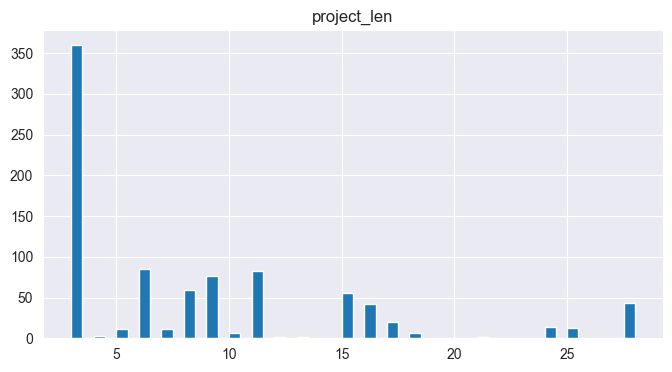

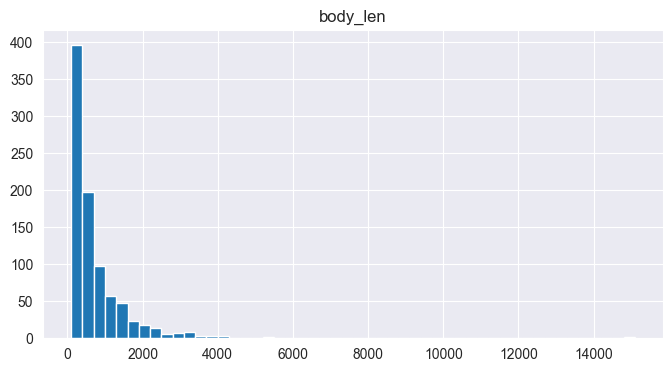

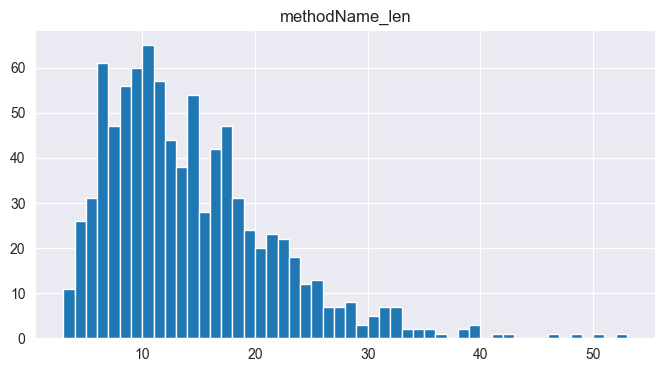

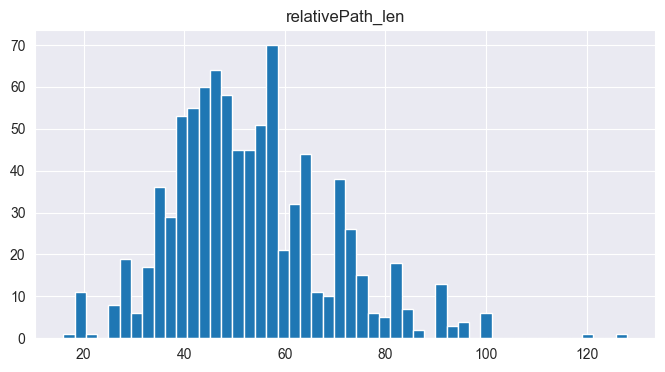

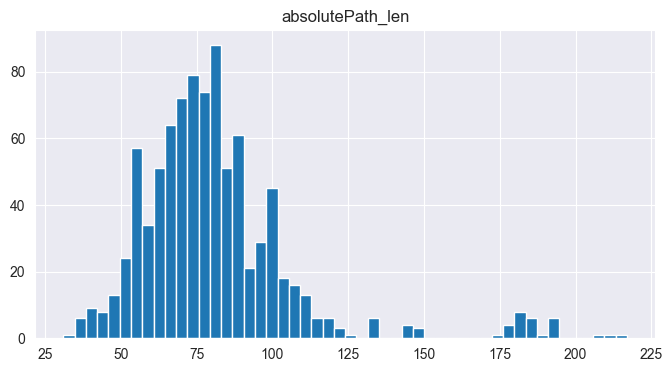

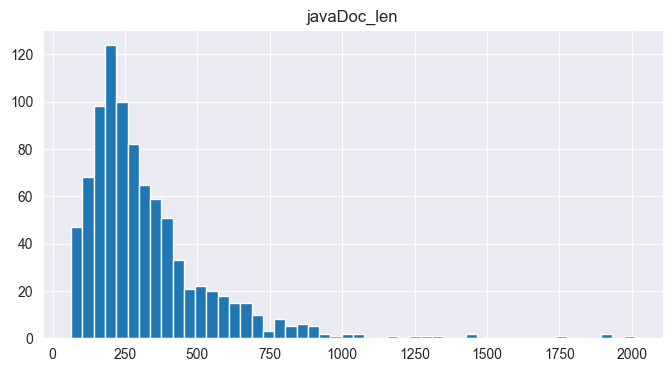

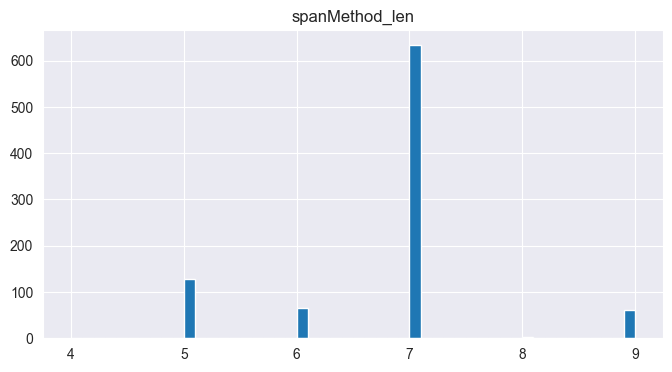

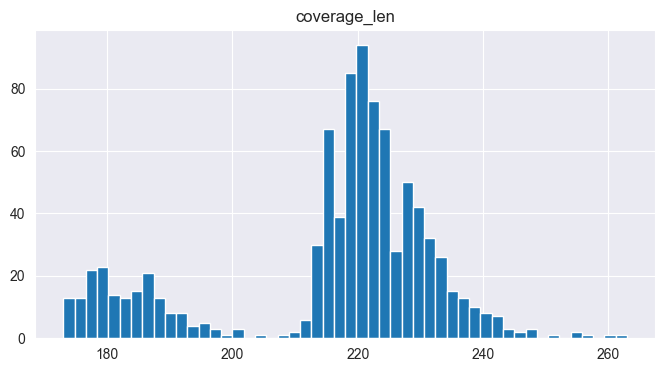

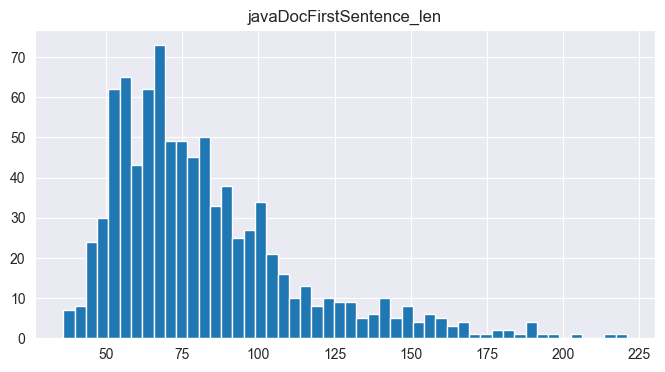

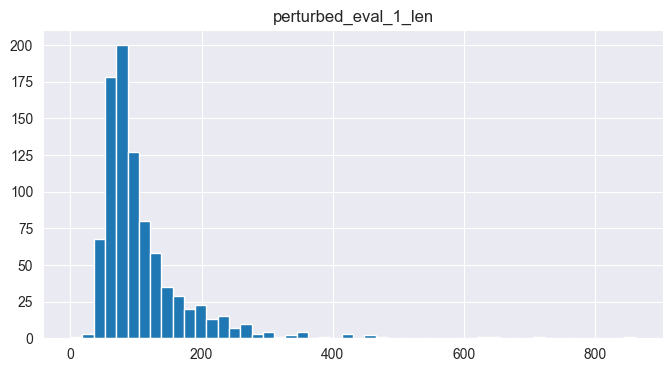

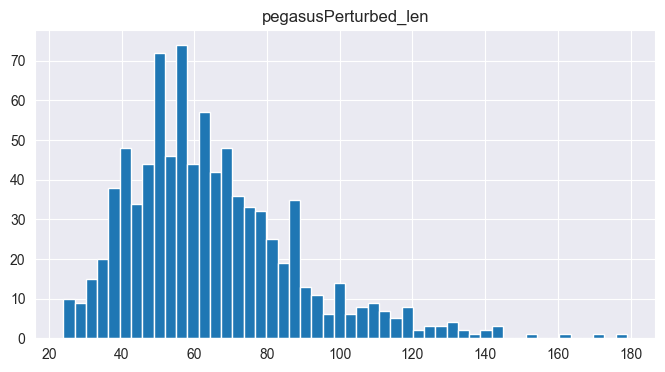

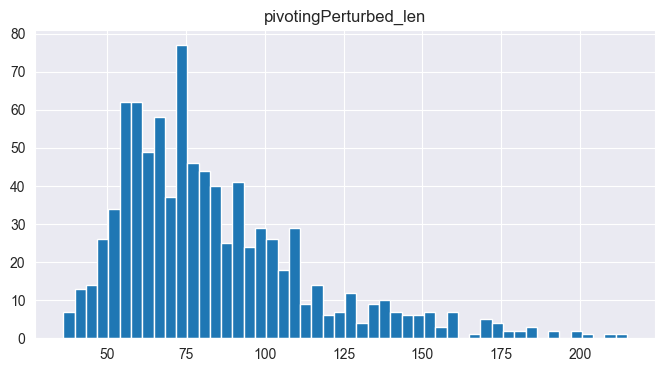

In [23]:
for col in length_cols:
    plt.figure(figsize=(8, 4))

    plt.hist(
        df[col],
        bins=50
    )

    plt.title(col)

    plt.show()

14. Аналіз проектів

In [24]:
if "project" in df.columns:
    print(
        "Projects:",
        df["project"].nunique()
    )

    display(
        df["project"]
        .value_counts()
        .head(20)
    )

Projects: 33


project
cdk                             360
matsim-libs                      77
acs-aem-commons                  56
weblogic-kubernetes-operator     43
tablesaw                         43
dcache                           41
jackson-databind                 40
egeria                           30
glowstone                        27
dataverse                        22
openapi-generator                20
liquibase                        16
logstash-logback-encoder         14
anserini                         14
jeromq                           13
shardingsphere-elasticjob        13
jooby                            10
metrics                           9
mybatis-3                         7
cron-utils                        6
Name: count, dtype: int64

15. Графік проектів

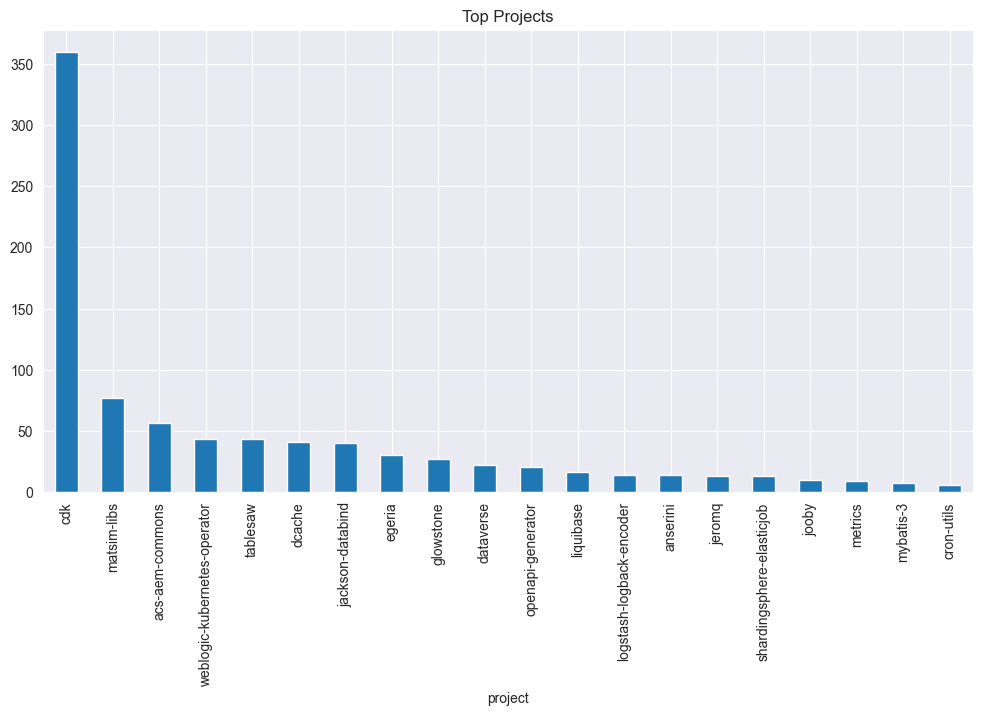

In [25]:
if "project" in df.columns:

    top_projects = (
        df["project"]
        .value_counts()
        .head(20)
    )

    plt.figure(figsize=(12,6))

    top_projects.plot.bar()

    plt.title("Top Projects")

    plt.show()

16. Аналіз методів

In [26]:
if "body" in df.columns:

    df["method_tokens"] = (
        df["body"]
        .fillna("")
        .str.split()
        .apply(len)
    )

    df["method_tokens"].describe()

17. Гістограма токенів методу

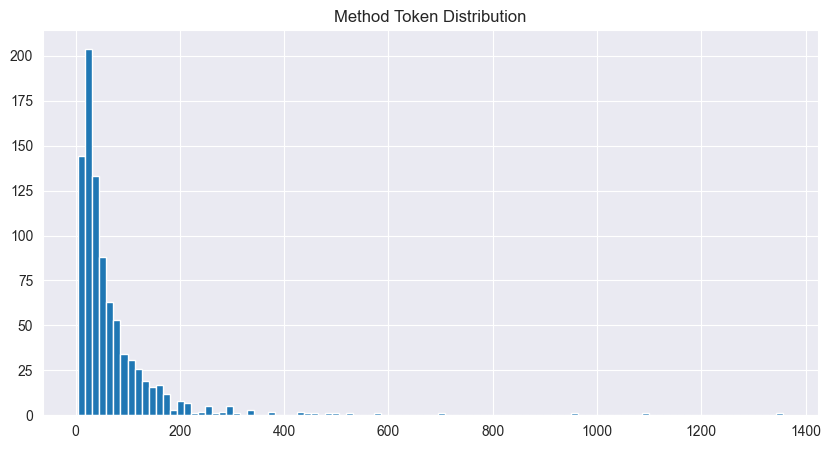

In [27]:
if "method_tokens" in df.columns:

    plt.figure(figsize=(10,5))

    plt.hist(
        df["method_tokens"],
        bins=100
    )

    plt.title(
        "Method Token Distribution"
    )

    plt.show()

18. Аналіз JavaDoc

In [28]:
if "javaDocFirstSentence" in df.columns:

    df["doc_tokens"] = (
        df["javaDocFirstSentence"]
        .fillna("")
        .str.split()
        .apply(len)
    )

    display(
        df["doc_tokens"]
        .describe()
    )

count    892.000000
mean      13.369955
std        4.772009
min        3.000000
25%       10.000000
50%       12.000000
75%       15.000000
max       35.000000
Name: doc_tokens, dtype: float64

19. Порівняння довжин коду і документації

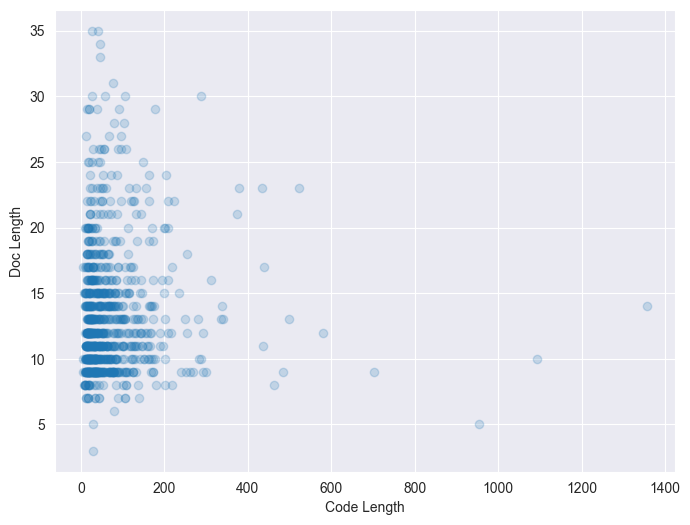

In [29]:
if (
    "method_tokens" in df.columns
    and
    "doc_tokens" in df.columns
):

    plt.figure(figsize=(8,6))

    plt.scatter(
        df["method_tokens"],
        df["doc_tokens"],
        alpha=0.2
    )

    plt.xlabel("Code Length")

    plt.ylabel("Doc Length")

    plt.show()

20. Кореляції

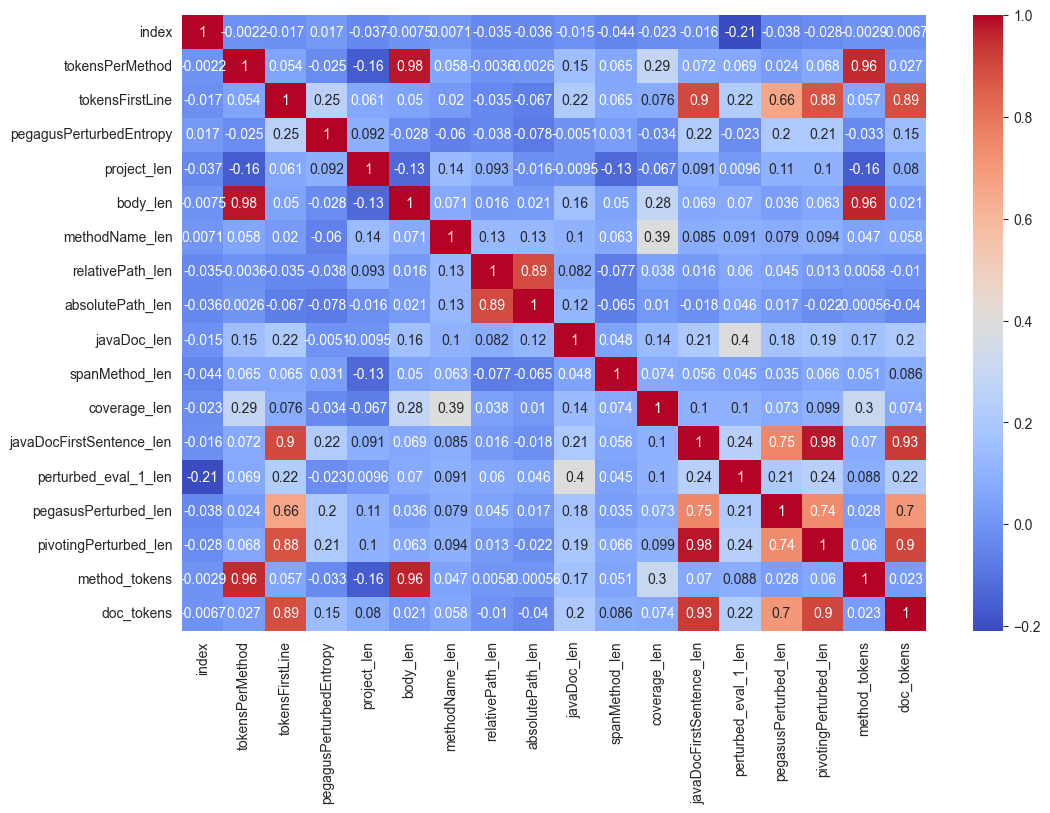

In [30]:
numeric_cols = df.select_dtypes(
    include=np.number
)

corr = numeric_cols.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

21. Аналіз перефразувань

In [31]:
paraphrase_cols = [
    c for c in df.columns
    if "perturbed" in c.lower()
]

paraphrase_cols

['perturbed_eval_1',
 'pegasusPerturbed',
 'pegagusPerturbedEntropy',
 'pivotingPerturbed',
 'perturbed_eval_1_len',
 'pegasusPerturbed_len',
 'pivotingPerturbed_len']

22. Довжини перефразувань

In [32]:
for col in paraphrase_cols:

    df[f"{col}_tokens"] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.split()
        .apply(len)
    )

23. Порівняння оригіналу і перефразування

In [33]:
compare_cols = [
    "javaDocFirstSentence"
] + paraphrase_cols

display(
    df[
        compare_cols
    ].sample(10)
)

,javaDocFirstSentence,perturbed_eval_1,pegasusPerturbed,pegagusPerturbedEntropy,pivotingPerturbed,perturbed_eval_1_len,pegasusPerturbed_len,pivotingPerturbed_len
82,The Graham Scan algorithm determines the points belonging to the convex hull in O(n lg n).,The points belonging to the convex hull in O(n lg n) are determined by the Graham Scan algorithm,The points belonging to the hull are determined by the Graham Scan.,0.362464,The Graham Scan algorithm determines the points belonging to the convex shell in O(n lg n).,96,67,93
443,Quick check to see whether <i>both</i> the links are shorter than the given threshold.,"Given a couple of links and a thresholdLength, check if both the links are shorted than the threshold.",Check to see if the links are shorter than the threshold.,0.275633,Quickly check if <i>the two</i> links are shorter than the given threshold.,102,57,75
167,Is the {@code mapping} of the stereochemistry in the query preserved in the target.,The {@code} mapping of the stereochemistry in the query is stored in the destination,Is the query preserved in the target?,0.223971,Is the {mapping @code} of the stereochemistry in the query preserved in the target?,84,37,85
567,Adds the specified class to the list of {@link VFS} implementations.,A new class is added to the list of {@link VFS} implementations.,The specified class is added to the list of VFS implementations.,0.513935,Adds the specified class to the list of implementations {@link VFS}.,64,64,68
130,"Generate a compact element for an atom, such as a circle or a square, rather than text element.","Instead of a text element for an atom, a compact element such as a circle or square is generated",A circle or square is a better fit for an atom than a text element.,0.700671,"Generate a compact element for an atom, such as a circle or square, rather than a text element.",96,67,97
434,"Given a bond length for a model, calculate the scale that will transform this length to the on screen bond length in RendererModel.",Compute the scale for transforming the bond length to the on screen bond length for the RendererModel,"If you give a bond length for a model, calculate the scale that will transform it to the on screen bond length.",0.210352,"Given the binding length of a model, calculate the scale that will turn that length into the link length on the screen in RendererModel.",101,111,136
836,Takes the given Z Matrix coordinates and converts them to cartesian coordinates.,"Transforms the supplied Z Matrix coordinates to cartesian coordinates. The first atom is found at the point of origin, the second is found on the x-axis, and the third is found in the XY plane. Applying the Zmatrix distances, angles, and dihedrals adds the remaining information. Angles have a degree value.",The Z Matrix coordinates are converted to cartesian coordinates.,0.477558,Takes the coordinates of the given Z matrix and converts them to Cartesian coordinates.,308,64,87
421,Open a property file that is embedded as a Java resource and parse it.,Open and parse a property file embedded as a Java resource.,You can open a property file that is embedded in a Java resource.,0.299277,Open an embedded properties file as a Java resource and parse it.,59,65,65
23,Scan for help fields: fh_(= full help) or hh_(= help hint).,Allows you to scan for help fields: fh_(= full help) or hh_(= help hint).,Scan for help fields: fh_(full help) or hh_(help hint).,0.643585,Look for the help fields: fh_(= full help) or hh_(= help index).,73,55,66
152,Converts a {@link Model} into an {@link IAtomContainer} using the given {@link IChemObjectBuilder}.,Using the {@link IChemObjectBuilder} given converts a {@link Model} to a {@link IAtomContainer},The model is converted into an IAtomContainer using the given IChemObjectBuilder.,0.346445,Converts a {@link Model} to {@link IAtomContainer} using the given {@link IChemObjectBuilder}.,95,81,96


24. Найдовші методи

In [34]:
df.nlargest(
    10,
    "method_tokens"
)[
    [
        "project",
        "methodName",
        "method_tokens"
    ]
]

,project,methodName,method_tokens
244,cdk,readPropertiesFast,1356
510,cdk,writeMolecule,1094
525,matsim-libs,clusterInput,955
470,cdk,readChemFile,702
703,cdk,readChemFile,580
486,cdk,distributePartners,523
219,cdk,generateAtomContainerFromInchi,500
166,cdk,calculate,484
560,cdk,addDoubleBondStereochemistry,463
698,cdk,testSubgraphHeuristics,440


25. Найдовші JavaDoc

In [35]:
df.nlargest(
    10,
    "doc_tokens"
)[
    [
        "project",
        "methodName",
        "doc_tokens"
    ]
]

,project,methodName,doc_tokens
260,cdk,toCharge,35
320,cdk,buildRGraph,35
776,cdk,splitAfter,34
809,cdk,splitBefore,33
267,jackson-databind,primitiveType,31
107,weblogic-kubernetes-operator,updateExporterSidecars,30
311,cdk,parse,30
328,jackson-databind,closeOnFailAndThrowAsIOE,30
382,tablesaw,stratifiedSampleSplit,30
42,weblogic-kubernetes-operator,split,29


26. Збереження статистики

In [36]:
summary = pd.DataFrame({
    "rows": [len(df)],
    "columns": [len(df.columns)],
    "projects": [
        df["project"].nunique()
        if "project" in df.columns
        else None
    ]
})

summary.to_csv(
    "dataset_summary.csv",
    index=False
)

summary

,rows,columns,projects
0,892,37,33
